# Create_Sign

In [ ]:
###############

# Collage_Labelling

In [29]:
import sys
sys.path.append("CollageLabelling")

import importlib
import CollageLabelling
importlib.reload(CollageLabelling)

from CollageLabelling import Image_Merger

In [30]:
img_lb_path = "./circle_cutout.png"
img_bg_path = "./Resource/BG_1.jpg"
merger = Image_Merger(img_lb_path, img_bg_path)

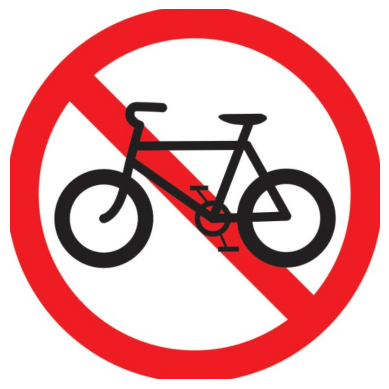

In [31]:
merger.Show_lb()

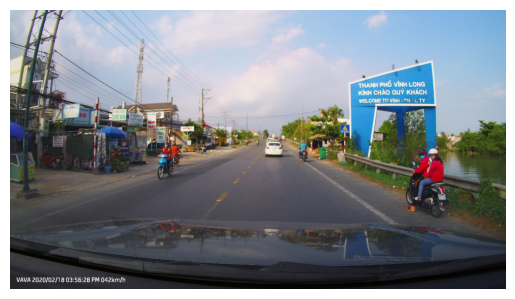

In [32]:
merger.Show_bg()

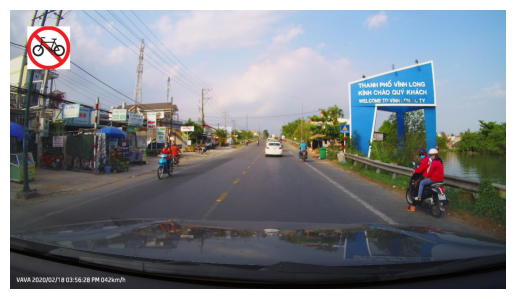

In [33]:
merger.ShowMerge(0.2, 0.2, 50, 50)

In [7]:
import cv2
import numpy as np

# Đọc ảnh
image = cv2.imread("./Resource/Bien_1.jpg", cv2.IMREAD_UNCHANGED)  # Đọc ảnh gốc

h, w = image.shape[:2]
# Xác định tâm và bán kính hình tròn
center_x, center_y = w // 2, h // 2  # Tâm ảnh
radius = min(w, h) // 2

# Tạo ảnh mask có cùng kích thước ảnh gốc, ban đầu là đen (0)
mask = np.zeros((h, w), dtype=np.uint8)

# Vẽ hình tròn trắng lên mask tại vị trí cần cắt
cv2.circle(mask, (center_x, center_y), radius, 255, -1)

# Tạo ảnh mới với kênh alpha (4 kênh: B, G, R, A)
result = np.zeros((h, w, 4), dtype=np.uint8)

# Copy ảnh gốc vào vùng có hình tròn, thêm kênh alpha
result[:, :, :3] = image  # Sao chép 3 kênh BGR
result[:, :, 3] = mask  # Gán mask vào kênh alpha (để tạo nền trong suốt)

# Cắt phần hình tròn ra (loại bỏ vùng thừa)
x1, y1 = max(0, center_x - radius), max(0, center_y - radius)  # Góc trên trái của vùng cắt
x2, y2 = min(w, center_x + radius), min(h, center_y + radius)  # Góc dưới phải

circle_crop = result[y1:y2, x1:x2]  # Cắt đúng hình tròn

# Lưu ảnh dưới dạng PNG (để giữ nền trong suốt)
cv2.imwrite("circle_cutout.png", circle_crop)

# # Hiển thị ảnh kết quả
# cv2.imshow("Circle Cutout", circle_crop)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


True

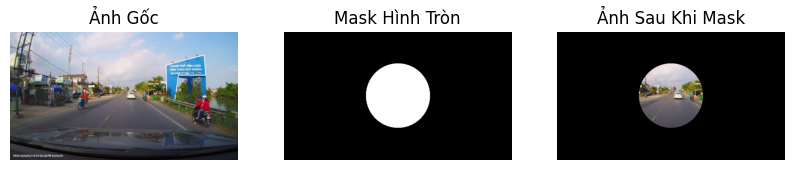

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh gốc
image = cv2.imread(img_bg_path)

# Lấy kích thước ảnh
height, width = image.shape[:2]

# Tạo mask cùng kích thước ảnh (mặc định toàn màu đen - 0)
mask = np.zeros((height, width), dtype=np.uint8)

# Vẽ một hình tròn trắng trên mask
center_x, center_y = width // 2, height // 2  # Tâm hình tròn ở giữa ảnh
radius = min(width, height) // 4  # Bán kính = 1/4 chiều nhỏ hơn của ảnh
cv2.circle(mask, (center_x, center_y), radius, 255, -1)

# Áp dụng mask lên ảnh
masked_image = cv2.bitwise_and(image, image, mask=mask)

# Hiển thị ảnh gốc, mask và ảnh sau khi áp dụng mask
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Ảnh Gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask Hình Tròn")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
plt.title("Ảnh Sau Khi Mask")
plt.axis("off")

plt.show()

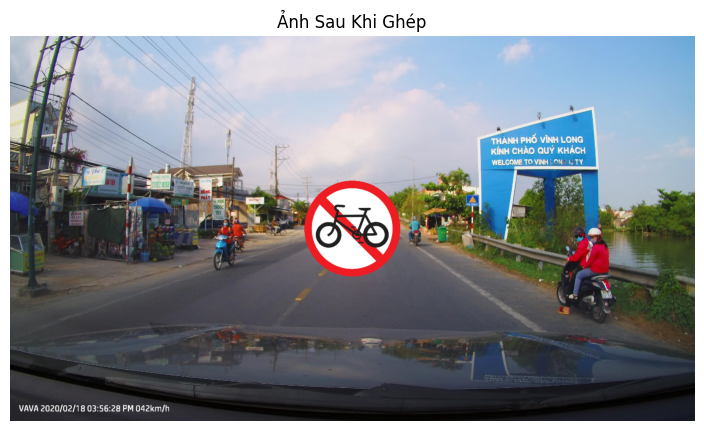

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh nền (ảnh chính)
background = cv2.imread(img_bg_path)

# Đọc ảnh ghép (ảnh có nền trong suốt)
overlay = cv2.imread("./circle_cutout.png", cv2.IMREAD_UNCHANGED)  # Đọc cả kênh alpha

# Kích thước ảnh nền
h_bg, w_bg = background.shape[:2]

# Resize ảnh overlay để phù hợp với kích thước mong muốn
overlay = cv2.resize(overlay, (200, 200))  # Resize về 200x200 (hoặc kích thước mong muốn)

# Lấy kích thước ảnh overlay
h_ol, w_ol = overlay.shape[:2]

# Xác định vị trí đặt overlay (ví dụ: ở giữa ảnh nền)
x, y = (w_bg - w_ol) // 2, (h_bg - h_ol) // 2  # Căn giữa

# Tách các kênh màu và kênh alpha từ ảnh overlay
b, g, r, alpha = cv2.split(overlay)

# Tạo mask từ kênh alpha (vùng có nội dung = 1, vùng trong suốt = 0)
mask = alpha / 255.0  # Chuyển alpha về 0-1

# Lấy vùng ảnh nền tương ứng với overlay
roi = background[y:y+h_ol, x:x+w_ol]

# Áp dụng mask để chỉ giữ lại vùng overlay có nội dung
for c in range(3):  # Lặp qua B, G, R
    roi[:, :, c] = (1 - mask) * roi[:, :, c] + mask * overlay[:, :, c]

# Gán vùng đã ghép vào ảnh nền
background[y:y+h_ol, x:x+w_ol] = roi

# Hiển thị ảnh kết quả
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Ảnh Sau Khi Ghép")
plt.show()
